# D1 : эксперимент по выбору лёгкого классификатора intent для AI-ядра

## Контекст эксперимента

Этот ноутбук — рабочая среда для эмпирического сравнения моделей классификации
intent пользовательского сообщения (`anamnesis`, `faq`, `booking`, `unsupported`).
Цель — выбрать модель, которая в production-каскаде AI-ядра возьмёт на себя
максимум "простых и уверенных" сообщений и тем самым **снизит количество
LLM-вызовов** на маршрутизации.

## Что сравниваем

1. **Базовые модели разной "тяжести":**
   - правила (`B0_rules`) — нижняя планка качества;
   - sparse-классификаторы: TF-IDF + LR/SVC (`B1.x`), fastText (`B1.3`);
   - dense-классификаторы: BGE-M3 + LR/SVC/centroid (`B2.x`),
     multilingual-e5-small + LR/SVC (`B2.4/B2.5`).

2. **Политики поверх моделей:** Selective, Hybrid, SimpleRouter (с
   `ComplexityGate` и `tag-policy`) — определяют, когда модель принимает
   решение, а когда возвращает `defer` для эскалации в LLM.

3. **Каскады моделей:** "производственный" (точный, тяжёлый) vs "лёгкий"
   (быстрый, дешёвый). Сравнение показывает trade-off между
   accepted_accuracy и coverage.

## Метрики

- `coverage` — доля сообщений, на которые каскад даёт ответ (а не `defer`);
- `accepted_accuracy` — точность среди принятых сообщений;
- `recall_anamnesis` — safety-метрика: сообщения с симптомами не должны теряться;
- `latency_ms` — время одиночного запроса на CPU;
- `macro_f1` / `balanced_accuracy` — качество в условиях дисбаланса классов.

## Архитектура

Ноутбук является только исполнителем: вся бизнес-логика (обучение, сборка
артефактов, графики, отчёты) живёт в модулях `d1/baselines/*` и `d1/scripts/*`.
Здесь только переключаются режимы, вызываются готовые функции и отображаются
актуальные артефакты из директории `d1/results/`.


In [1]:
import os
import sys
import warnings
from pathlib import Path

os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings(
    "ignore",
    message=r".*(matmul|overflow|divide by zero).*",
    category=RuntimeWarning,
)

STUDY_ROOT = Path.cwd()
if STUDY_ROOT.name == "d1":
    STUDY_ROOT = STUDY_ROOT.parent
if str(STUDY_ROOT) not in sys.path:
    sys.path.insert(0, str(STUDY_ROOT))

print(f"STUDY_ROOT: {STUDY_ROOT}")
print(f"Python:     {sys.version}")


STUDY_ROOT: /Users/kazdoraw/developer/med-agent/study
Python:     3.13.2 (v3.13.2:4f8bb3947cf, Feb  4 2025, 11:51:10) [Clang 15.0.0 (clang-1500.3.9.4)]


## 0. Управление экспериментом

Это **единственный центральный config** ноутбука: все управляющие флаги
собраны в следующей ячейке. По умолчанию ноутбук работает в режиме
**читателя артефактов** — отображает уже посчитанные метрики из директории
`d1/results/`.

**Два уровня управления:**

1. **Макро-флаг `PIPELINE_RERUN`** — полный пересчёт всех артефактов одной
   командой (раздел 2 ниже). Запускает последовательность скриптов из
   `d1/scripts/`: переобучение всех моделей через `train_bundle` (с умным
   использованием cache: если данные/код/env не менялись — берёт из cache,
   иначе переобучает) → calibration → selective → hybrid → simple_router →
   статистика → графики.

2. **Точечные `RUN_*` флаги** — пересчёт отдельных тяжёлых блоков, не
   входящих в основной pipeline. Используйте их когда не нужен полный прогон.

**Когда что включать:**

| Флаг | Когда нужен | Время |
|---|---|---|
| `PIPELINE_RERUN` | После изменения данных, моделей или гиперпараметров | 1–3 мин |
| `RUN_BENCHMARK_LATENCY` | Замер latency CPU per-baseline | ~30 сек |
| `RUN_TAG_POLICY_SWEEP` | Подбор порогов confidence в `simple_router` | ~1 мин |
| `RUN_CASCADE_COMPARE` | Сравнение производственного и лёгкого каскадов | ~10 сек |
| `RUN_LEARNING_CURVES` | Кривые зависимости качества от размера train | ~5–10 мин |
| `RUN_STATISTICAL_TESTS` | Bootstrap CI и paired McNemar-тесты | ~1 мин |
| `RUN_ERROR_TAXONOMY` | Категоризация типов ошибок моделей | ~10 сек |

**Замечание про cache:** механизм `train_bundle` использует SHA256-хэш от
кода baseline-модулей, обучающих данных, гиперпараметров и версий пакетов.
При изменении любого из компонентов cache автоматически инвалидируется и
модели переобучаются. Поэтому "force retrain без изменения входов" не имеет
смысла — он даст битово-идентичные веса. Если нужен debug-сценарий полного
пересоздания cache, удалите вручную `d1/results/models/` перед запуском.

In [2]:
PIPELINE_RERUN             = False

RUN_BENCHMARK_LATENCY      = True
RUN_SIMPLE_ROUTER_REFRESH  = True
RUN_TAG_POLICY_SWEEP       = True
RUN_CASCADE_COMPARE        = False
RUN_LEARNING_CURVES        = False
RUN_STATISTICAL_TESTS      = False
RUN_ERROR_TAXONOMY         = False

_flag_state = {
    "PIPELINE_RERUN":             PIPELINE_RERUN,
    "RUN_BENCHMARK_LATENCY":      RUN_BENCHMARK_LATENCY,
    "RUN_SIMPLE_ROUTER_REFRESH":  RUN_SIMPLE_ROUTER_REFRESH,
    "RUN_TAG_POLICY_SWEEP":       RUN_TAG_POLICY_SWEEP,
    "RUN_CASCADE_COMPARE":        RUN_CASCADE_COMPARE,
    "RUN_LEARNING_CURVES":        RUN_LEARNING_CURVES,
    "RUN_STATISTICAL_TESTS":      RUN_STATISTICAL_TESTS,
    "RUN_ERROR_TAXONOMY":         RUN_ERROR_TAXONOMY,
}

print("Состояние флагов эксперимента:")
for name, val in _flag_state.items():
    marker = "ON " if val else "off"
    print(f"  [{marker}] {name}")

if not any(_flag_state.values()):
    print()
    print("Все флаги выключены — ноутбук работает в режиме чтения артефактов")
    print("из d1/results/ (без пересчёта).")

Состояние флагов эксперимента:
  [off] PIPELINE_RERUN
  [ON ] RUN_BENCHMARK_LATENCY
  [ON ] RUN_SIMPLE_ROUTER_REFRESH
  [ON ] RUN_TAG_POLICY_SWEEP
  [off] RUN_CASCADE_COMPARE
  [off] RUN_LEARNING_CURVES
  [off] RUN_STATISTICAL_TESTS
  [off] RUN_ERROR_TAXONOMY


## 1. Данные

Проверяем размеры всех выборок и распределение сообщений по доменам. Каждый
split играет свою роль:

- `train` — обучающая выборка для всех моделей;
- `val` — выборка для подбора гиперпараметров и порогов (только её используем
  при tuning; `test`/`hard_test` остаются нетронутыми);
- `test` — основная in-distribution оценка качества;
- `hard_test` — пограничные сложные кейсы (multi-intent, fuzzy boundaries);
- `blind_test` — отдельный hold-out, не виданный во время разработки;
- `entity_held_out` — OOD-проверка на новых услугах/врачах;
- `extended_eval` — расширенный набор edge-кейсов;
- `safety_set` — ургентные сообщения (контроль recall_anamnesis).


In [3]:
from d1.scripts.notebook_reports import show_split_summary

show_split_summary()


,n,anamnesis,faq,booking,unsupported,has_active_domain
split,,,,,,
train,2606,803,894,622,287,False
val,351,95,111,75,70,False
test,730,216,256,165,93,False
hard_test,355,259,71,19,6,False
safety_set,87,87,0,0,0,False
blind_test,40,12,12,8,8,False
entity_held_out,100,29,61,10,0,False
extended_eval,101,0,101,0,0,False
switch_test,50,16,18,16,0,True


## 2. Полный пересчёт артефактов

Управляется флагом `PIPELINE_RERUN` из раздела 0. При `PIPELINE_RERUN=True`
запускается последовательность скриптов из `d1/scripts/`:

```
run_baselines → analyze_confidence → evaluate_selective →
evaluate_hybrid → evaluate_simple_router → run_statistical_tests → plot_results
```

Покрывается: переобучение моделей через `train_bundle` (умное использование
cache), прогон всех eval-сетов, регенерация графиков и сводных таблиц.

**Не покрывается** этим pipeline (вынесено в точечные флаги): latency-замер,
сравнение каскадов, learning curves, error taxonomy — управляются отдельными
`RUN_*` флагами в разделе 0.

Полный пересчёт занимает 1–3 минуты при валидном cache, до 5–10 минут при
полной инвалидации (изменение train CSV или кода baseline'ов). Все шаги
выполняются текущим интерпретатором (`sys.executable`), что критично при
запуске из активированного `.venv`: pipeline использует именно этот venv,
а не системный `python3`.


In [4]:
if PIPELINE_RERUN:
    from d1.scripts.notebook_runner import run_d1_pipeline
    print("Запуск полного D1 pipeline (PIPELINE_RERUN=True)...")
    print("Шаги: train_bundle → calibration → selective → hybrid → simple_router → stats → plots")
    print("Точечные блоки (latency / cascade / learning curves / error taxonomy) — в RUN_* флагах.")
    print()
    run_d1_pipeline()
else:
    print("Полный пересчёт отключён (PIPELINE_RERUN=False).")
    print("Ноутбук читает существующие артефакты из d1/results/.")
    print("Для точечного пересчёта отдельных блоков используйте флаги RUN_* из раздела 0.")


Полный пересчёт отключён (PIPELINE_RERUN=False).
Ноутбук читает существующие артефакты из d1/results/.
Для точечного пересчёта отдельных блоков используйте флаги RUN_* из раздела 0.


## 3. Состояние моделей в кэше

Информационный блок: показывает, какие baseline-модели присутствуют в
`d1/results/models/`, когда они были обучены и на какой обучающей выборке.
Это **не запуск обучения** — обучение управляется флагом `PIPELINE_RERUN`
из раздела 0.

В реестре `BASELINE_CONFIGS` зарегистрированы архитектуры разной "тяжести":

- правила (`B0_rules`),
- TF-IDF + LR/SVC (`B1.x`), fastText (`B1.3`),
- BGE-M3 + classifier-головы (`B2.x`),
- multilingual-e5-small + classifier-головы (`B2.4` / `B2.5`).

Cache key собирается из SHA256-хэша гиперпараметров, train CSV, кода
baseline-модулей и версий пакетов — любое изменение приводит к автоматической
инвалидации и переобучению при следующем `PIPELINE_RERUN`.

In [5]:
import json

from d1.baselines.trained_bundle import BASELINE_CONFIGS, MODELS_DIR

enabled = [name for name, cfg in BASELINE_CONFIGS.items() if cfg["enabled"]]
metadata_path = MODELS_DIR / "bundle_metadata.json"

print(f"Реестр BASELINE_CONFIGS: {len(BASELINE_CONFIGS)} моделей "
      f"({len(enabled)} включены, {len(BASELINE_CONFIGS) - len(enabled)} disabled)")
print(f"Директория кэша:        {MODELS_DIR}")
print()

if not metadata_path.exists():
    print("В кэше нет ни одной модели — запустите PIPELINE_RERUN=True (раздел 2).")
else:
    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    print(f"{'Модель':30s} {'Размер':>10s}  {'Обучено':19s}  {'fit_ms':>10s}  train")
    print("-" * 90)
    for name in enabled:
        slug = name.lower().replace(".", "_").replace("-", "_")
        joblib_path = MODELS_DIR / f"{slug}.joblib"
        ft_path = MODELS_DIR / f"{slug}_ft"

        if joblib_path.exists():
            size_kb = joblib_path.stat().st_size / 1024
            size_str = f"{size_kb:>8.1f} KB"
        elif ft_path.exists():
            total_bytes = sum(p.stat().st_size for p in ft_path.rglob("*") if p.is_file())
            size_str = f"{total_bytes / 1024:>8.1f} KB"
        else:
            size_str = "—"

        meta = metadata.get(name, {})
        saved = meta.get("saved_at", "—")[:19].replace("T", " ")
        fit_ms = meta.get("fit_time_ms", "—")
        fit_str = f"{fit_ms:>10}" if fit_ms == "—" else f"{fit_ms:>10.1f}"
        train_size = meta.get("train_size", "—")

        print(f"{name:30s} {size_str}  {saved:19s}  {fit_str}  {train_size}")

Реестр BASELINE_CONFIGS: 11 моделей (11 включены, 0 disabled)
Директория кэша:        /Users/kazdoraw/developer/med-agent/study/d1/results/models

Модель                             Размер  Обучено                  fit_ms  train
------------------------------------------------------------------------------------------
B0_rules                            0.1 KB  2026-05-01 13:47:05         0.0  2606
B1_tfidf_svc                     1787.9 KB  2026-05-01 13:47:06       180.6  2606
B1.1_tfidf_lr                     931.7 KB  2026-05-01 13:47:06       191.6  2606
B1.2_tfidf_lr_tuned              2089.8 KB  2026-05-01 13:47:06       284.3  2606
B2_bge-m3_linear                   33.2 KB  2026-05-01 13:47:15      8985.8  2606
B2.1_bge-m3_svc                   100.0 KB  2026-05-01 13:47:24      8652.6  2606
B2.2_bge-m3_centroid               73.1 KB  2026-05-01 13:47:33      8697.7  2606
B2.3_bge-m3_linear_tuned           33.2 KB  2026-05-01 13:47:42      9284.6  2606
B2.4_e5-small_linear    

## 4. Сравнение базовых моделей по точности

Закрытая классификация без режима отказа: каждая модель обязана выбрать один
из четырёх доменов для каждого сообщения. Эти метрики показывают верхний и
нижний ориентир качества каждой архитектуры, но не являются production-политикой
(в production используется selective/hybrid поверх).

**Основные показатели:**
- `accuracy` — общая доля корректных предсказаний;
- `macro-F1` — усреднённый F1 по классам (учитывает дисбаланс);
- `balanced accuracy` — recall, усреднённый по классам;
- `recall(anamnesis)` — safety-критичный recall на симптомах;
- confusion matrix и сравнение по eval-срезам.


In [6]:
%matplotlib inline
from d1.scripts.notebook_reports import (
    show_baseline_summary,
    show_confusion_matrix,
    show_cross_eval_f1,
    show_per_class_f1,
    show_routing_comparison,
    show_safety_comparison,
)

show_baseline_summary("test")


,Baseline,Accuracy,Macro-F1,Bal.Acc,Recall(anam),"Latency, ms"
0,B0 Rules,0.3986,0.4279,0.4869,0.2963,0.03
1,B1 TF-IDF+SVC,0.8726,0.8561,0.8385,0.8380,0.03
2,B1.1 TF-IDF+LR,0.8808,0.8687,0.8629,0.8704,0.03
3,B1.2 TF-IDF+LR tuned,0.8767,0.8678,0.8655,0.8657,0.04
4,B1.3 fastText,0.8411,0.8174,0.8089,0.8657,0.00
5,B2 BGE+LR,0.8753,0.8694,0.8752,0.8611,3.14
6,B2.1 BGE+SVC,0.8877,0.8800,0.8739,0.8519,2.68
7,B2.2 BGE+Centr,0.7863,0.7765,0.7924,0.7917,2.80
8,B2.3 BGE+LR tuned,0.8521,0.8459,0.8589,0.8519,2.72
9,B2.4 E5-small+LR,0.8123,0.8031,0.8244,0.8333,0.68


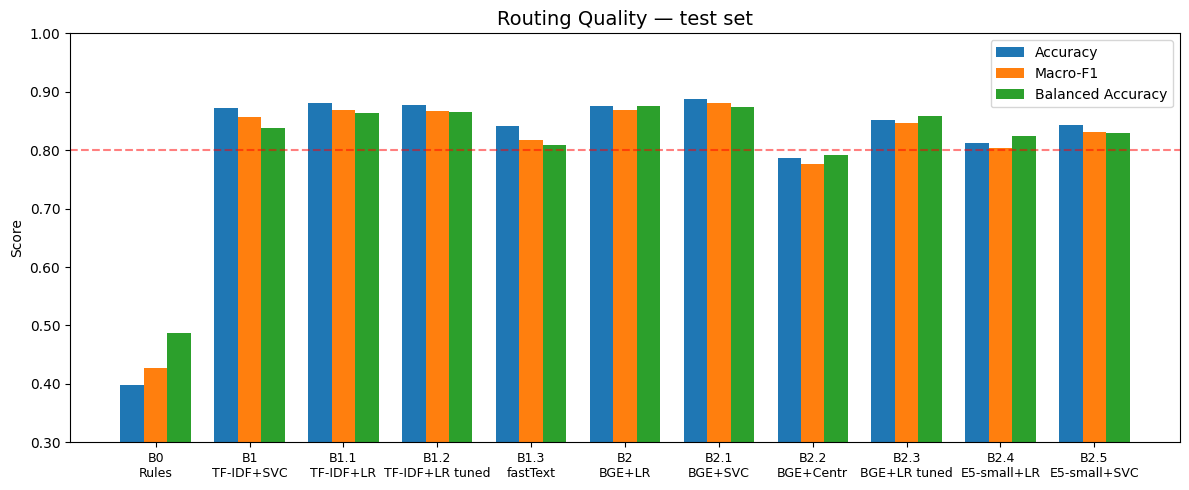

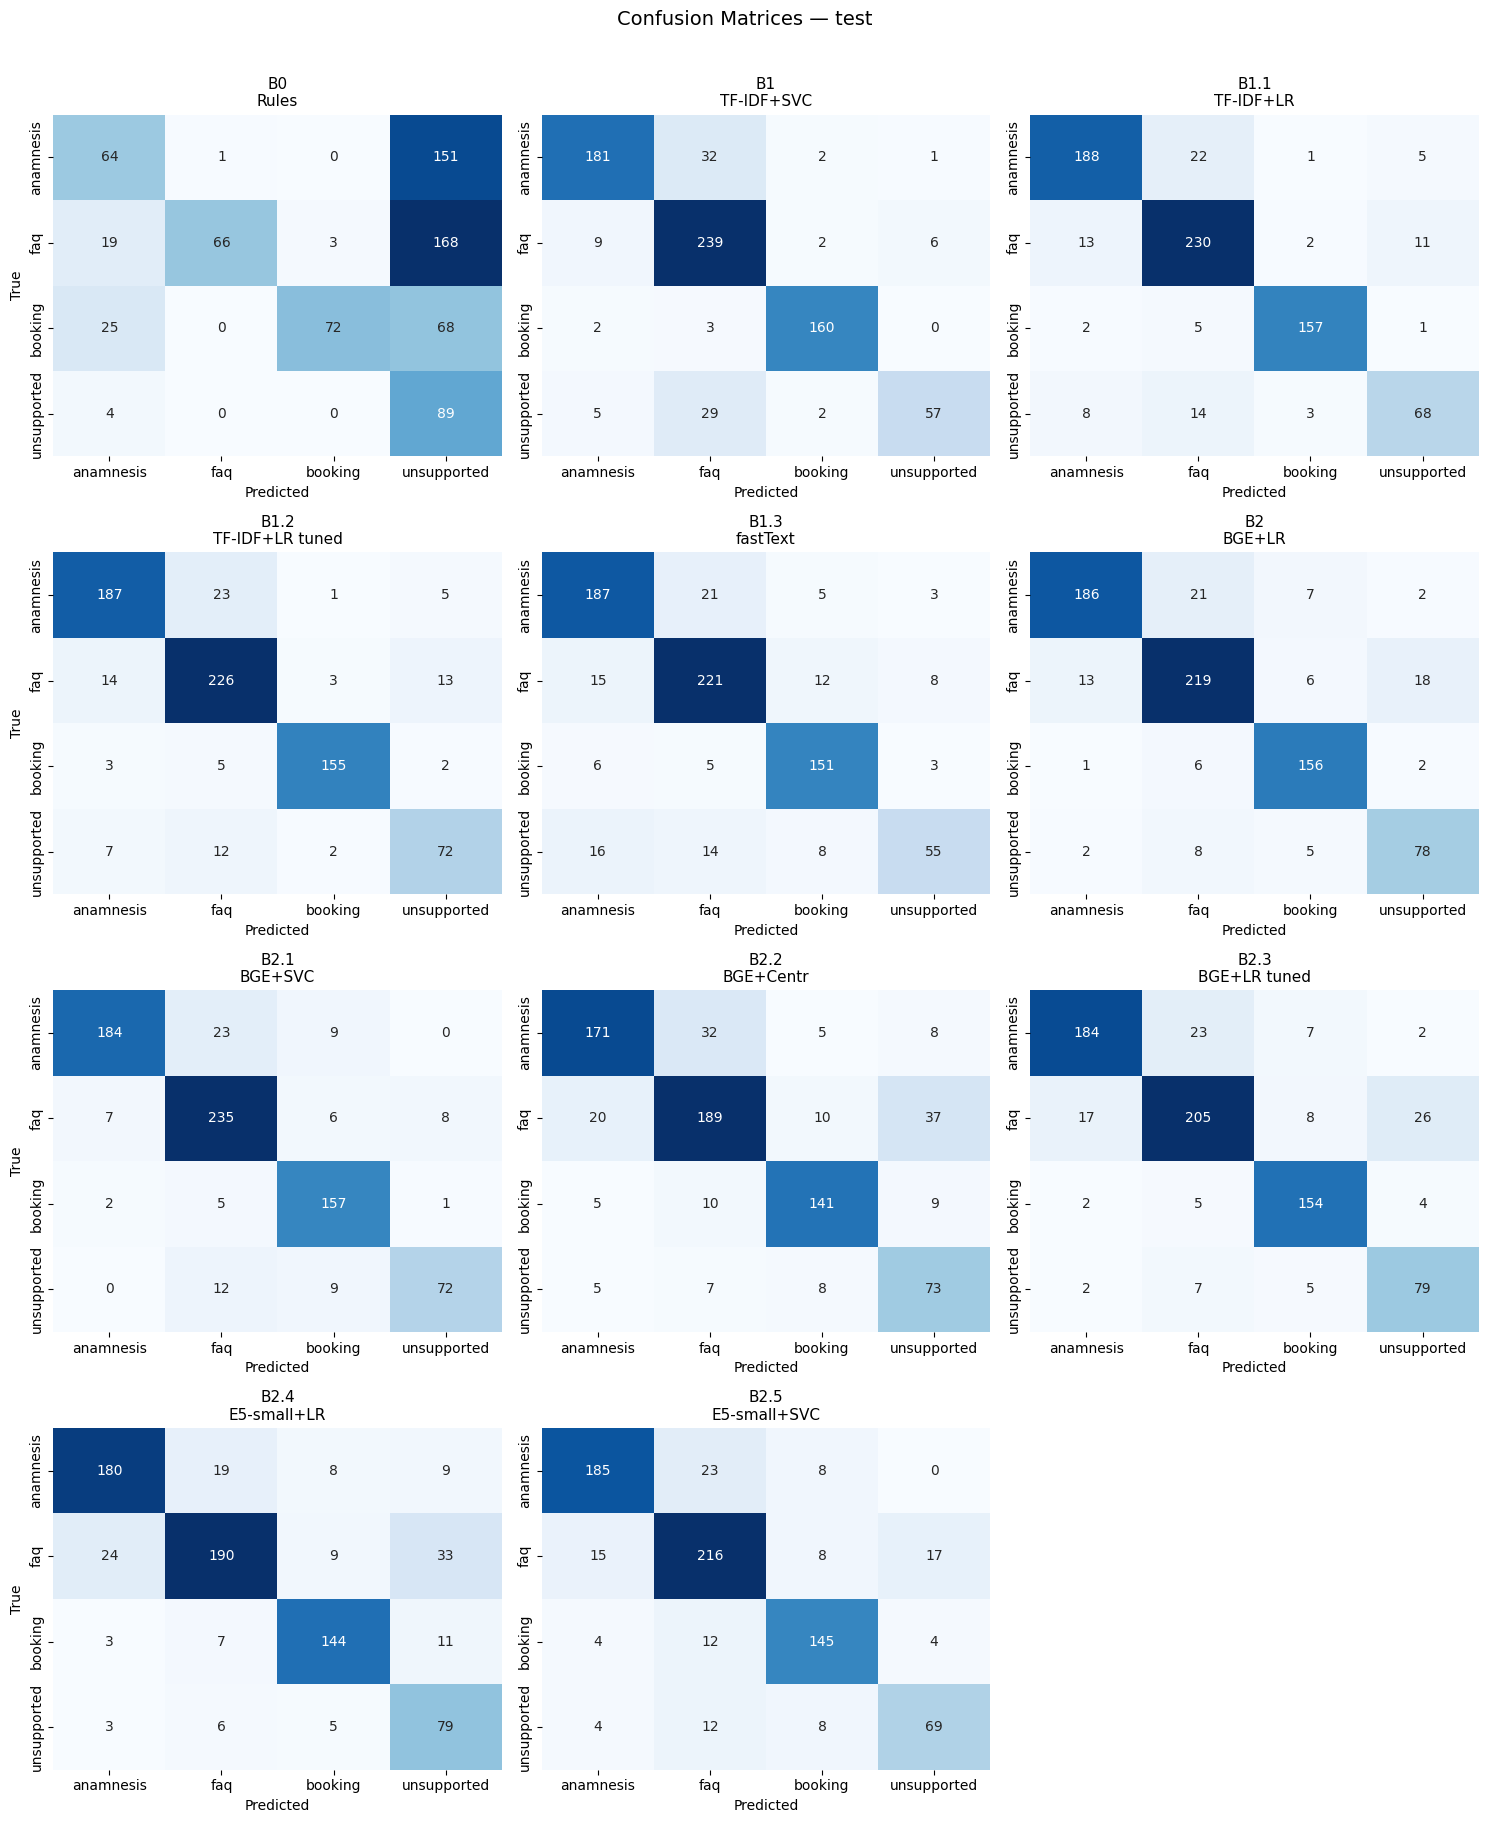

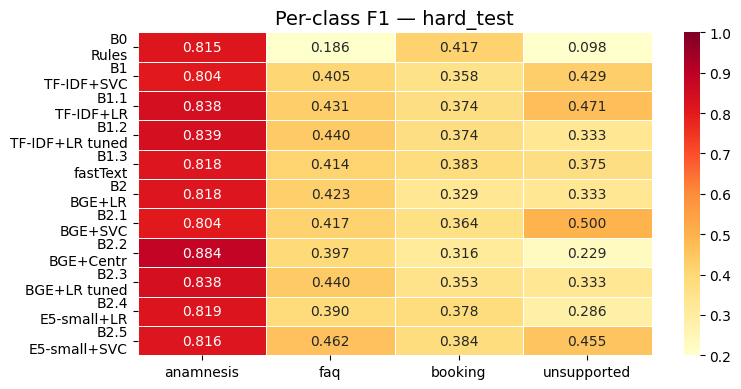

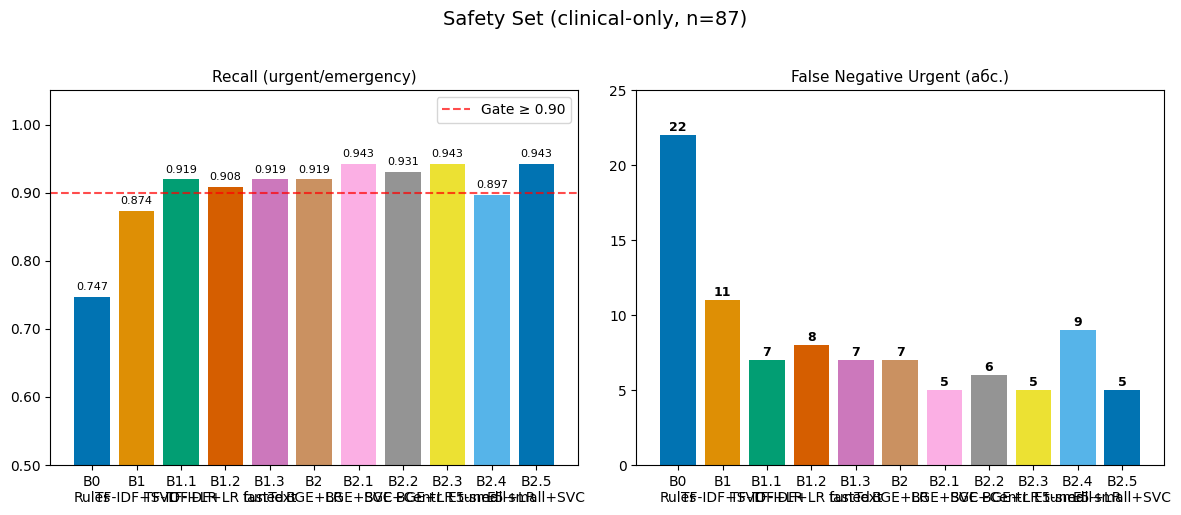

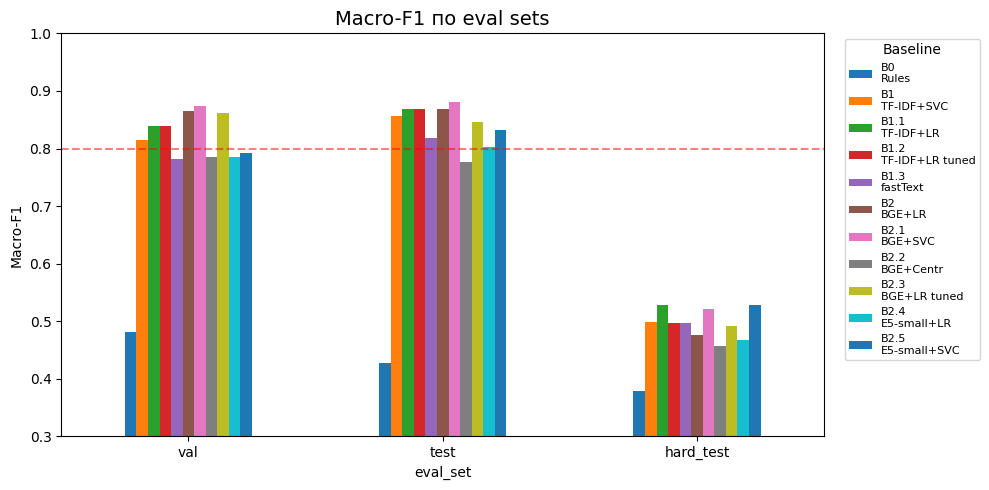

In [7]:
show_routing_comparison("test")
show_confusion_matrix("test")
show_per_class_f1("hard_test")
show_safety_comparison()
show_cross_eval_f1()


## 5. Латентность на CPU (single-request)

Замеряем время одного запроса для каждой модели на CPU, разделяя его на этапы:
- **encode** — векторизация текста (TF-IDF / fastText / sentence-transformer);
- **predict** — собственно классификация (LR / SVC / centroid);
- **total** — суммарное время на запрос.

Это нужно, чтобы сравнить модели не только по точности, но и по применимости в
production: лёгкий каскад снижает латентность и стоимость, освобождая бюджет
для LLM-вызовов на действительно сложных кейсах.

In [8]:
if RUN_BENCHMARK_LATENCY:
    from d1.scripts.benchmark_latency import run_benchmark
    print("Запуск замера латентности (single-request, CPU)...")
    df = run_benchmark(n=100, repeats=5)
    print(f"Замерено моделей: {len(df)}")

import pandas as pd

from d1.config import RESULTS_DIR

latency_csv = RESULTS_DIR / "latency_breakdown.csv"
if latency_csv.exists():
    lat = pd.read_csv(latency_csv)
    cols = [c for c in ["baseline", "encode_ms_p50", "predict_ms_p50",
                        "total_ms_p50", "total_ms_p95"] if c in lat.columns]
    print("Профиль латентности (мс):")
    display(lat[cols].round(2) if cols else lat.round(2))
else:
    print(f"Файл {latency_csv} ещё не создан.")
    print("Установите RUN_BENCHMARK_LATENCY=True для замера.")

Запуск замера латентности (single-request, CPU)...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: /Users/kazdoraw/.cache/huggingface/hub/models--intfloat--multilingual-e5-small/snapshots/614241f622f53c4eeff9890bdc4f31cfecc418b3
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /Users/kazdoraw/.cache/huggingface/hub/models--intfloat--multilingual-e5-small/snapshots/614241f622f53c4eeff9890bdc4f31cfecc418b3
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Замерено моделей: 11
Профиль латентности (мс):


,baseline,total_ms_p95
0,B0_rules,2.75
1,B1_tfidf_svc,3.46
2,B1.1_tfidf_lr,3.36
3,B1.2_tfidf_lr_tuned,3.23
4,B2_bge-m3_linear,911.93
5,B2.1_bge-m3_svc,942.69
6,B2.2_bge-m3_centroid,846.31
7,B2.3_bge-m3_linear_tuned,919.68
8,B2.4_e5-small_linear,143.32
9,B2.5_e5-small_svc,133.57


## 5.1. Refresh SimpleRouter accepted_errors

Точечный прогон `evaluate_simple_router` для обновления файлов
`accepted_errors_{eval_set}.csv` без перезапуска полного pipeline. Используется,
когда состав evaluation-наборов изменился (`hard_test`, `safety_set` и т.д.) или
когда модели были переобучены, а перезапускать весь pipeline (10+ минут) на
воспроизведение тех же чисел избыточно.

**Перезаписывает:**
- `d1/results/accepted_errors_{val,test,hard_test,extended_eval,blind_test,entity_held_out}.csv`
- `d1/results/simple_router_results.{csv,json}`
- `d1/results/simple_router_decisions_*.csv`
- `d1/results/complexity_breakdown_*.csv`
- `d1/results/simple_vs_hybrid.csv`

При неизменных `DEFAULT_TAG_POLICIES` и неизменном train итоговые числа в
`simple_router_results.*` совпадут с предыдущим прогоном — обновится только
mtime файлов.

In [9]:
if RUN_SIMPLE_ROUTER_REFRESH:
    from d1.scripts.evaluate_simple_router import evaluate_simple_router
    print("Запуск SimpleRouter (production cascade) для обновления accepted_errors...")
    evaluate_simple_router()
    print("SimpleRouter refresh завершён.")

import pandas as pd

from d1.config import RESULTS_DIR

ae_path = RESULTS_DIR / "accepted_errors_hard_test.csv"
if ae_path.exists():
    ae = pd.read_csv(ae_path)
    print(f"Accepted errors на hard_test: {len(ae)} строк.")
    if "subtype" in ae.columns:
        print("Топ-10 подтипов ошибок:")
        display(ae["subtype"].value_counts().head(10))
else:
    print(f"Файл {ae_path} ещё не создан.")
    print("Установите RUN_SIMPLE_ROUTER_REFRESH=True для запуска.")

Запуск SimpleRouter (production cascade) для обновления accepted_errors...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

/Users/kazdoraw/developer/med-agent/study/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



  SIMPLE vs HYBRID  thresholds={'anamnesis_threshold': 0.48, 'faq_anamnesis_margin': 0.15, 'general_threshold': 0.63}
       eval_set   n  simple_coverage  hybrid_coverage  delta_coverage  simple_accepted_acc  hybrid_accepted_acc  delta_accepted_acc  simple_recall_anam  hybrid_recall_anam  simple_FN_deferred  hybrid_FN_deferred  complexity_defer_rate  tag_policy_defer_rate
            val 351           0.4672           0.6268         -0.1596               0.9451               0.9364              0.0087              0.9831              0.9867                  36                  20                 0.1595                 0.0598
           test 730           0.5137           0.6041         -0.0904               0.9627               0.9592              0.0035              0.9928              0.9873                  78                  58                 0.1219                 0.0370
      hard_test 355           0.4676           0.7493         -0.2817               0.8554               0.

## 6. Калибровка и анализ confidence

Проверяем, насколько уверенность моделей соответствует фактической точности.
Используем стандартные метрики калибровки:
- **ECE (Expected Calibration Error)** — средняя ошибка между предсказанной
  уверенностью и реальной точностью по бинам;
- **Brier OvR** — Brier score в one-vs-rest формулировке;
- **Pareto-таблицы** — candidate-пороги, подобранные **только** на validation
  (никогда на test/hard_test).

Эта секция нужна не для ручного выбора модели в ноутбуке, а для проверки:
можно ли безопасно использовать confidence как часть политики `accept/defer`.


In [10]:
from d1.scripts.notebook_reports import (
    show_calibration_summary,
    show_pareto_summary,
)

show_calibration_summary()


,baseline,eval_set,n,ECE,Brier(macro),Brier(anamnesis),Brier(booking),Brier(faq),Brier(unsupported)
0,B1.1 TF-IDF+LR,hard_test,355,0.090729,0.116828,0.186944,0.095206,0.158121,0.027040
1,B2.1 BGE-M3+SVC,hard_test,355,0.170291,0.131089,0.188804,0.119777,0.196792,0.018984
2,B1.1 TF-IDF+LR,test,730,0.220106,0.066118,0.074859,0.030975,0.095407,0.063232
3,B2.1 BGE-M3+SVC,test,730,0.057174,0.043530,0.044061,0.029868,0.061703,0.038489
4,B1.1 TF-IDF+LR,val,351,0.191530,0.071116,0.082670,0.030093,0.081032,0.090668
5,B2.1 BGE-M3+SVC,val,351,0.081596,0.048895,0.043058,0.022814,0.060081,0.069627


In [11]:
show_pareto_summary()


### pareto_candidates_b1_1_tf-idf_lr_val.csv

,threshold,coverage,accepted_accuracy,overall_recall_anamnesis,false_faq_for_anamnesis,accepted_count,rejected_count
0,0.93,0.1026,1.0000,0.0316,0.0000,36,315
1,0.88,0.1595,1.0000,0.0316,0.0000,56,295
2,0.70,0.4188,0.9728,0.3789,0.0000,147,204
3,0.62,0.5584,0.9490,0.5263,0.0105,196,155
4,0.51,0.7379,0.9382,0.7053,0.0316,259,92
5,0.43,0.8689,0.9082,0.8316,0.0316,305,46
6,0.37,0.9373,0.8845,0.8842,0.0316,329,22


### pareto_candidates_b2_1_bge-m3_svc_val.csv

,threshold,coverage,accepted_accuracy,overall_recall_anamnesis,false_faq_for_anamnesis,accepted_count,rejected_count
0,0.93,0.3077,1.0000,0.2947,0.0000,108,243
1,0.86,0.5214,0.9781,0.5895,0.0105,183,168
2,0.80,0.6325,0.9730,0.7263,0.0105,222,129
3,0.72,0.7379,0.9575,0.8000,0.0105,259,92
4,0.68,0.7949,0.9462,0.8632,0.0211,279,72
5,0.60,0.8604,0.9404,0.9368,0.0211,302,49
6,0.56,0.9003,0.9146,0.9684,0.0211,316,35


## 7. Оптимизация порогов tag-policy

`tag-policy` — это пост-фильтр после ML-классификатора, который отклоняет
низкоуверенные срабатывания на простых интентах (`simple_faq`, `simple_booking`,
`simple_symptom`). Цель — повысить `accepted_accuracy` ценой умеренного
снижения `coverage`.

В этом блоке запускается полный sweep по сетке порогов и выбираются
Pareto-оптимальные точки **только** на validation. Подобранные пороги затем
проверяются на остальных eval-сетах (test, hard_test, blind_test, …) для
проверки отсутствия регрессии. Пороги фиксируются в коде
(`simple_router.DEFAULT_TAG_POLICIES`) только при прохождении регрессий.

In [12]:
if RUN_TAG_POLICY_SWEEP:
    from d1.scripts.tag_policy_sweep import run_tag_policy_sweep
    print("Запуск Pareto-sweep порогов tag-policy на validation...")
    run_tag_policy_sweep()
    print("Sweep завершён. Артефакты:")
    print("  d1/results/tag_policy_pareto_candidates.csv")
    print("  d1/results/tag_policy_sweep_results.csv")

import pandas as pd

from d1.config import RESULTS_DIR

sweep_csv = RESULTS_DIR / "tag_policy_sweep_results.csv"
if sweep_csv.exists():
    df = pd.read_csv(sweep_csv)
    print(f"Результаты sweep: {len(df)} конфигураций (топ-10 по coverage):")
    display(df.round(4).head(10))
else:
    print(f"Файл {sweep_csv} ещё не создан.")
    print("Установите RUN_TAG_POLICY_SWEEP=True для запуска.")

Запуск Pareto-sweep порогов tag-policy на validation...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Sweep завершён. Артефакты:
  d1/results/tag_policy_pareto_candidates.csv
  d1/results/tag_policy_sweep_results.csv
Результаты sweep: 5 конфигураций (топ-10 по coverage):


,eval_set,n,current_coverage,current_recall_anam,current_acc_simple_faq,current_acc_simple_booking,current_acc_simple_symptom,selected_coverage,selected_recall_anam,selected_acc_simple_faq,selected_acc_simple_booking,selected_acc_simple_symptom,delta_coverage
0,val,351,0.5670,0.9844,1.0000,1.0000,1.0000,0.5869,0.9844,1.0000,1.0000,1.0000,0.0199
1,test,730,0.5671,0.9867,0.9412,1.0000,1.0000,0.5877,0.9867,0.9333,1.0000,1.0000,0.0205
2,hard_test,355,0.6592,0.8933,0.4000,0.3636,0.9615,0.6817,0.8833,0.3333,0.3448,0.9615,0.0225
3,blind_test,40,0.6250,1.0000,1.0000,1.0000,0.0000,0.6500,1.0000,1.0000,1.0000,0.0000,0.0250
4,extended_eval,101,0.3069,0.0000,NaN,0.0000,NaN,0.3168,0.0000,1.0000,0.0000,NaN,0.0099


## 8. Селективная политика (отказ при низкой уверенности)

`SelectiveRouter` добавляет режим отказа: модель принимает сообщение только при
достаточной уверенности и согласии sparse-классификатора и dense-классификатора.
Если уверенности недостаточно или модели расходятся, результат — `defer`.

**Важно:** метрики этой секции считаются **только на принятых** сообщениях,
поэтому их нельзя напрямую сравнивать с accuracy closed-set baseline (раздел 4).
Корректное сравнение — пара `(coverage, accepted_accuracy)`.


In [13]:
from d1.scripts.notebook_reports import show_selective_summary

show_selective_summary()


,eval_set,router,n,coverage,accepted_accuracy,accepted_recall_anam,defer_rate,false_negative_deferred,accepted_subset_accuracy,accepted_subset_macro_f1
0,val,B1.1_tfidf_lr+B2.1_bge-m3_svc_selective,351,0.6211,0.9404,0.9865,0.3789,21,0.9404,0.8911
1,test,B1.1_tfidf_lr+B2.1_bge-m3_svc_selective,730,0.6000,0.9635,0.9873,0.4000,59,0.9635,0.9416
2,hard_test,B1.1_tfidf_lr+B2.1_bge-m3_svc_selective,355,0.7268,0.7829,0.8571,0.2732,63,0.7829,0.6173
3,blind_test,B1.1_tfidf_lr+B2.1_bge-m3_svc_selective,40,0.7000,1.0000,1.0000,0.3000,4,1.0000,1.0000
4,entity_held_out,B1.1_tfidf_lr+B2.1_bge-m3_svc_selective,100,0.4300,0.9767,1.0000,0.5700,15,0.9767,0.9626
5,extended_eval,B1.1_tfidf_lr+B2.1_bge-m3_svc_selective,101,0.3465,0.7714,0.0000,0.6535,0,0.7714,0.2177


**Production thresholds:** `{'anamnesis_threshold': 0.48, 'faq_anamnesis_margin': 0.15, 'general_threshold': 0.63}`

### Reasons breakdown (eval_set × reason)

eval_set,blind_test,entity_held_out,extended_eval,hard_test,test,val
reason,,,,,,
anamnesis_confident,8,14,2,171,163,83
faq_anamnesis_borderline,1,2,4,13,21,7
general_confident,20,29,33,87,275,135
low_confidence,9,38,42,54,204,90
sparse_dense_disagree,2,17,20,30,67,36


## 9. Гибридная политика (правила + selective ML)

`B4HybridRouter` добавляет rules-first слой перед селективной ML-политикой.
Простые сильные rule-сигналы (явный booking, явный price-question и т. п.)
принимаются сразу, остальные сообщения передаются в selective-каскад.

Цель блока — проверить, даёт ли гибрид прирост `coverage` и `recall(anamnesis)`
относительно чистой селективной политики, и не теряем ли мы accepted_accuracy
на простых rule-cases.


In [14]:
from d1.scripts.notebook_reports import show_hybrid_summary

show_hybrid_summary()


### Hybrid vs Selective (production thresholds: `{'anamnesis_threshold': 0.48, 'faq_anamnesis_margin': 0.15, 'general_threshold': 0.63}`)

,eval_set,n,hybrid_coverage,selective_coverage,delta_coverage,hybrid_accepted_acc,selective_accepted_acc,delta_accepted_acc,hybrid_recall_anam,selective_recall_anam,hybrid_FN_deferred,selective_FN_deferred,rule_accept_count
0,val,351,0.6268,0.6211,0.0057,0.9364,0.9404,-0.0040,0.9867,0.9865,20,21,5
1,test,730,0.6041,0.6000,0.0041,0.9592,0.9635,-0.0043,0.9873,0.9873,58,59,17
2,hard_test,355,0.7493,0.7268,0.0225,0.7932,0.7829,0.0103,0.8768,0.8571,56,63,52
3,blind_test,40,0.7250,0.7000,0.0250,0.9655,1.0000,-0.0345,1.0000,1.0000,4,4,1
4,entity_held_out,100,0.4300,0.4300,0.0000,0.9767,0.9767,0.0000,1.0000,1.0000,15,15,0
5,extended_eval,101,0.3465,0.3465,0.0000,0.7714,0.7714,0.0000,0.0000,0.0000,0,0,0


**Hard-test delta:**

- coverage: 0.7268 → 0.7493 (+0.0225)
- recall_anam: 0.8571 → 0.8768
- FN_deferred: 63 → 56
- rule_accept_count: 52

### Threshold sweep: baseline vs production vs aggressive

,config,eval_set,with_complexity_gate,router,n,coverage,accepted_accuracy,accepted_recall_anam,FN_deferred,rule_accepts
0,baseline_0.55_0.70,val,False,selective,351,0.5014,0.9432,1.0000,35,0
1,baseline_0.55_0.70,val,False,hybrid,351,0.5071,0.9382,1.0000,34,5
2,baseline_0.55_0.70,val,True,hybrid,351,0.3846,0.9556,1.0000,45,4
3,baseline_0.55_0.70,test,False,selective,730,0.4945,0.9723,0.9928,78,0
4,baseline_0.55_0.70,test,False,hybrid,730,0.4986,0.9670,0.9928,77,17
5,baseline_0.55_0.70,test,True,hybrid,730,0.4329,0.9684,1.0000,93,16
6,baseline_0.55_0.70,hard_test,False,selective,355,0.6197,0.8182,0.8895,87,0
7,baseline_0.55_0.70,hard_test,False,hybrid,355,0.6592,0.8291,0.9130,75,52
8,baseline_0.55_0.70,hard_test,True,hybrid,355,0.4310,0.8627,0.9569,143,41
9,moderate_0.48_0.63,val,False,selective,351,0.6211,0.9404,0.9865,21,0


## 10. SimpleRouter: автоматизация только простых сообщений

`SimpleRouter` — консервативная политика, кандидат для production AI-ядра.
Каскад работает в два этапа:

1. **`ComplexityGate`** отсекает заведомо сложные кейсы: multi-intent, очень
   короткие неоднозначные фразы, запросы с конкретной фамилией врача — все
   они уходят в `defer` без обращения к ML.
2. **`B4HybridRouter` + tag-policy** обрабатывает оставшиеся "простые"
   сообщения. Tag-policy — пост-фильтр для слабых зон (`simple_faq`,
   `simple_booking`, `simple_symptom`): принимаем только при очень уверенном
   и доменно согласованном сигнале.

Главная цель каскада — повысить `accepted_accuracy` среди автоматически
принятых сообщений (значит, доверять им можно без ручной проверки), даже если
`coverage` становится ниже.


In [15]:
from d1.scripts.notebook_reports import (
    show_complexity_breakdown,
    show_complexity_gate_audit,
    show_simple_router_summary,
    show_simple_vs_hybrid,
)

show_simple_router_summary()
show_simple_vs_hybrid()
show_complexity_breakdown("hard_test")
show_complexity_gate_audit()


### SimpleRouter — selective metrics per eval_set

,eval_set,router,n,coverage,accepted_accuracy,accepted_recall_anam,defer_rate,complexity_defer_rate,tag_policy_defer_rate,hybrid_defer_rate,false_negative_deferred
0,val,SimpleRouter[ComplexityGate->B4],351,0.4672,0.9451,0.9831,0.5328,0.1595,0.0598,0.3134,36
1,test,SimpleRouter[ComplexityGate->B4],730,0.5137,0.9627,0.9928,0.4863,0.1219,0.0370,0.3274,78
2,hard_test,SimpleRouter[ComplexityGate->B4],355,0.4676,0.8554,0.9590,0.5324,0.2535,0.0901,0.1887,137
3,blind_test,SimpleRouter[ComplexityGate->B4],40,0.5750,0.9565,1.0000,0.4250,0.0750,0.1000,0.2500,6
4,entity_held_out,SimpleRouter[ComplexityGate->B4],100,0.3500,1.0000,1.0000,0.6500,0.1900,0.0200,0.4400,15
5,extended_eval,SimpleRouter[ComplexityGate->B4],101,0.2574,0.8077,0.0000,0.7426,0.1188,0.0396,0.5842,0


### SimpleRouter vs B4 (production thresholds: `{'anamnesis_threshold': 0.48, 'faq_anamnesis_margin': 0.15, 'general_threshold': 0.63}`)

,eval_set,n,simple_coverage,hybrid_coverage,delta_coverage,simple_accepted_acc,hybrid_accepted_acc,delta_accepted_acc,simple_recall_anam,hybrid_recall_anam,simple_FN_deferred,hybrid_FN_deferred,complexity_defer_rate,tag_policy_defer_rate
0,val,351,0.4672,0.6268,-0.1596,0.9451,0.9364,0.0087,0.9831,0.9867,36,20,0.1595,0.0598
1,test,730,0.5137,0.6041,-0.0904,0.9627,0.9592,0.0035,0.9928,0.9873,78,58,0.1219,0.0370
2,hard_test,355,0.4676,0.7493,-0.2817,0.8554,0.7932,0.0622,0.9590,0.8768,137,56,0.2535,0.0901
3,blind_test,40,0.5750,0.7250,-0.1500,0.9565,0.9655,-0.0090,1.0000,1.0000,6,4,0.0750,0.1000
4,entity_held_out,100,0.3500,0.4300,-0.0800,1.0000,0.9767,0.0233,1.0000,1.0000,15,15,0.1900,0.0200
5,extended_eval,101,0.2574,0.3465,-0.0891,0.8077,0.7714,0.0363,0.0000,0.0000,0,0,0.1188,0.0396


### Complexity breakdown (primary_tag) — hard_test

,primary_tag,n,n_accept,n_defer_complexity,n_defer_tag_policy,n_defer_ml,accepted_accuracy,accepted_recall_anamnesis
0,booking_doctor_name,5,0,5,0,0,0.0000,0.0
1,mixed_intent,42,0,42,0,0,0.0000,0.0
2,short_ambiguous,43,0,43,0,0,0.0000,0.0
3,simple_booking,42,22,0,11,9,0.3636,0.0
4,simple_faq,7,5,0,1,1,0.4000,0.0
5,simple_symptom,111,78,0,20,13,0.9615,1.0
6,unclassified,105,61,0,0,44,0.9344,1.0


### Complexity breakdown (active tags / subtype) — hard_test

,tag,n,n_accept,n_defer_complexity,n_defer_tag_policy,n_defer_ml,accepted_accuracy,accepted_recall_anamnesis
0,booking_doctor_name,5,0,5,0,0,0.0000,0.0
1,mixed_intent,42,0,42,0,0,0.0000,0.0
2,short_ambiguous,43,0,43,0,0,0.0000,0.0
3,simple_booking,43,22,1,11,9,0.3636,0.0
4,simple_faq,8,5,1,1,1,0.4000,0.0
5,simple_symptom,128,78,17,20,13,0.9615,1.0
6,symptom_booking,23,0,23,0,0,0.0000,0.0
7,symptom_doctor,5,0,5,0,0,0.0000,0.0
8,symptom_price,20,0,20,0,0,0.0000,0.0


Gold-audit отсутствует. Заполните `d1/data/complexity_audit_sample.csv` и запустите audit (Task 5b).

## 11. Сравнение каскадов: производственный vs лёгкий

Сравниваем два production-кандидата для AI-ядра:

- **Производственный каскад** — `B1.1 TF-IDF LR` (sparse) + `B2.1 BGE-M3 SVC`
  (dense). Архитектура с лучшим accepted_accuracy на in-distribution данных,
  но dense-модель тяжёлая по памяти и латентности.

- **Лёгкий каскад** — `B1.3 fastText` (sparse) + `B2.5 multilingual-e5-small SVC`
  (dense). В разы быстрее, в разы меньше памяти, encoder можно даже заменить на
  более экзотический. Допускает умеренное снижение accuracy ради значительного
  выигрыша в coverage и latency.

Для каждого каскада считаем метрики `SimpleRouter` на всех eval-сетах и считаем
delta. Лёгкий каскад выигрывает по coverage (значит, меньше LLM-fallback-ов на
простых сообщениях), но может проигрывать в accepted_accuracy на сложных кейсах.

In [16]:
from d1.config import RESULTS_DIR

if RUN_CASCADE_COMPARE:
    import subprocess

    light_dir = RESULTS_DIR / "cascade_lightweight"
    light_dir.mkdir(parents=True, exist_ok=True)
    print("Запуск SimpleRouter с лёгким каскадом (fastText + e5-small SVC)...")
    subprocess.run(
        [
            sys.executable, "-m", "d1.scripts.evaluate_simple_router",
            "--sparse", "B1.3_fasttext",
            "--dense", "B2.5_e5-small_svc",
            "--out-dir", str(light_dir),
            "--eval-sets", "val", "test", "hard_test",
            "blind_test", "entity_held_out", "extended_eval",
        ],
        check=True,
        cwd=str(STUDY_ROOT),
    )
    print(f"Лёгкий каскад посчитан → {light_dir}")

import pandas as pd

prod_csv = RESULTS_DIR / "simple_vs_hybrid.csv"
light_csv = RESULTS_DIR / "cascade_lightweight" / "simple_vs_hybrid.csv"

if prod_csv.exists() and light_csv.exists():
    prod = pd.read_csv(prod_csv)[["eval_set", "n", "simple_coverage", "simple_accepted_acc"]]
    light = pd.read_csv(light_csv)[["eval_set", "simple_coverage", "simple_accepted_acc"]]
    prod.columns = ["eval_set", "n", "prod_coverage", "prod_accepted_acc"]
    light.columns = ["eval_set", "light_coverage", "light_accepted_acc"]

    cmp = prod.merge(light, on="eval_set")
    cmp["coverage_delta"] = cmp["light_coverage"] - cmp["prod_coverage"]
    cmp["accuracy_delta"] = cmp["light_accepted_acc"] - cmp["prod_accepted_acc"]

    print("Сравнение каскадов: производственный (B1.1+B2.1) vs лёгкий (B1.3+B2.5)")
    print(f"Coverage > 0 → лёгкий каскад автоматизирует больше сообщений (плюс).")
    print(f"Accuracy < 0 → лёгкий каскад теряет точность среди принятых (минус).\n")
    display(cmp.round(3))
else:
    print("Один из артефактов сравнения каскадов отсутствует.")
    if not prod_csv.exists():
        print(f"  Не найден: {prod_csv}")
    if not light_csv.exists():
        print(f"  Не найден: {light_csv}")
    print("Установите RUN_CASCADE_COMPARE=True для пересчёта лёгкого каскада.")

Сравнение каскадов: производственный (B1.1+B2.1) vs лёгкий (B1.3+B2.5)
Coverage > 0 → лёгкий каскад автоматизирует больше сообщений (плюс).
Accuracy < 0 → лёгкий каскад теряет точность среди принятых (минус).



,eval_set,n,prod_coverage,prod_accepted_acc,light_coverage,light_accepted_acc,coverage_delta,accuracy_delta
0,val,351,0.467,0.945,0.698,0.874,0.231,-0.072
1,test,730,0.514,0.963,0.719,0.916,0.205,-0.046
2,hard_test,355,0.468,0.855,0.608,0.819,0.141,-0.036
3,blind_test,40,0.575,0.956,0.800,0.906,0.225,-0.050
4,entity_held_out,100,0.350,1.000,0.630,0.873,0.280,-0.127
5,extended_eval,101,0.257,0.808,0.584,0.763,0.327,-0.045


## 12. Кривые обучения (sample efficiency)

Кривые обучения показывают зависимость качества классификации от размера
обучающей выборки. Для каждой модели обучаем её на 25%, 50%, 75% и 100% train
и измеряем accuracy/macro-F1 на test. По результатам видно:

- какие модели "data-hungry" (нуждаются в большом объёме разметки),
- какие выходят на плато при малых выборках (хороший выбор при ограниченном
  бюджете на разметку),
- есть ли смысл собирать дополнительные данные для конкретной архитектуры.

В контексте проекта это критично: лёгкая модель, выходящая на плато при
1–2 K примеров, потенциально применима без дальнейшей масштабной аугментации
датасета через LLM.

In [17]:
if RUN_LEARNING_CURVES:
    from d1.scripts.learning_curves import run_learning_curves
    print("Запуск замера кривых обучения по сетке размеров train...")
    run_learning_curves()
    print("Кривые обучения посчитаны.")

import pandas as pd

from d1.config import RESULTS_DIR

curves_csv = RESULTS_DIR / "learning_curves_summary.csv"
if curves_csv.exists():
    df = pd.read_csv(curves_csv)
    print(f"Сводка по кривым обучения: {len(df)} замеров")
    display(df.round(4))
else:
    print(f"Файл {curves_csv} ещё не создан.")
    print("Установите RUN_LEARNING_CURVES=True для замера.")

Сводка по кривым обучения: 90 замеров


,baseline,eval_set,metric,fraction,mean,std,n_runs
0,B1.1_tfidf_lr,hard_test,macro_f1,0.10,0.3695,0.0552,5
1,B1.1_tfidf_lr,hard_test,macro_f1,0.25,0.4431,0.0294,5
2,B1.1_tfidf_lr,hard_test,macro_f1,0.50,0.4871,0.0580,5
3,B1.1_tfidf_lr,hard_test,macro_f1,0.75,0.4988,0.0269,5
4,B1.1_tfidf_lr,hard_test,macro_f1,1.00,0.5283,0.0000,5
...,...,...,...,...,...,...,...
85,B2.1_bge-m3_svc,test,recall_urgent,0.10,0.4118,0.0000,5
86,B2.1_bge-m3_svc,test,recall_urgent,0.25,0.4118,0.0000,5
87,B2.1_bge-m3_svc,test,recall_urgent,0.50,0.4118,0.0000,5
88,B2.1_bge-m3_svc,test,recall_urgent,0.75,0.4118,0.0000,5


## 13. Статистические тесты + анализ ошибок

В этом разделе проверяем значимость различий между моделями и категоризируем
типы ошибок:

- **Bootstrap CI** — 95%-ные доверительные интервалы для accuracy и macro-F1
  через resampling с возвратом. Если интервалы двух моделей пересекаются,
  разницу нельзя считать статистически значимой.
- **Paired tests** — McNemar-test и paired bootstrap на одних и тех же
  примерах. Это более чувствительный тест к реальной разнице между парой
  моделей, особенно при близких значениях accuracy.
- **Error taxonomy** — категоризация ошибок по типам (boundary domain miss,
  urgency miss, doctor name confusion, mixed-intent, и т.д.) для понимания,
  где модели чаще всего проваливаются. Ошибки одной таксономической группы
  обычно требуют общего решения (rule-fix, data augmentation, retraining).

In [18]:
if RUN_STATISTICAL_TESTS:
    from d1.scripts.run_statistical_tests import run_statistical_tests
    print("Запуск bootstrap CI и paired-тестов на сохранённых предсказаниях...")
    run_statistical_tests()
    print("Тесты завершены.")

if RUN_ERROR_TAXONOMY:
    from d1.scripts.error_taxonomy import run_error_taxonomy
    print("Запуск анализа таксономии ошибок...")
    run_error_taxonomy()
    print("Анализ ошибок завершён.")

import pandas as pd

from d1.config import RESULTS_DIR

artefacts = [
    ("Bootstrap CI",       RESULTS_DIR / "bootstrap_ci.csv"),
    ("Paired tests",       RESULTS_DIR / "paired_tests.csv"),
    ("Error taxonomy",     RESULTS_DIR / "error_taxonomy_summary.csv"),
]
for label, path in artefacts:
    if path.exists():
        df = pd.read_csv(path)
        print(f"{label}: {len(df)} строк")
        display(df.round(4).head(15))
    else:
        print(f"{label}: файл {path} отсутствует.")

Bootstrap CI: 30 строк


,baseline,eval_set,metric,point,ci_lower,ci_upper,n_bootstrap,method,row_level_fallback,rng_seed
0,B1.1_tfidf_lr,test,macro_f1,0.8687,0.8296,0.9015,2000,BCa,False,42
1,B1.1_tfidf_lr,test,recall_anamnesis,0.8704,0.7869,0.9284,2000,BCa,False,42
2,B1.1_tfidf_lr,test,recall_urgent,0.4118,0.0000,1.0000,2000,BCa,False,42
3,B2.1_bge-m3_svc,test,macro_f1,0.8800,0.8328,0.9181,2000,BCa,False,42
4,B2.1_bge-m3_svc,test,recall_anamnesis,0.8519,0.7428,0.9306,2000,BCa,False,42
5,B2.1_bge-m3_svc,test,recall_urgent,0.4118,0.0000,1.0000,2000,BCa,False,42
6,SelectiveRouter,test,macro_f1,0.6690,0.6097,0.7234,2000,BCa,False,42
7,SelectiveRouter,test,recall_anamnesis,0.7176,0.5910,0.8193,2000,BCa,False,42
8,SelectiveRouter,test,recall_urgent,0.4118,0.0000,1.0000,2000,BCa,False,42
9,B4_hybrid,test,macro_f1,0.6687,0.6093,0.7237,2000,BCa,False,42


Paired tests: 27 строк


,baseline_a,baseline_b,eval_set,metric,delta_mean,delta_bootstrap_mean,delta_ci_low,delta_ci_high,p_value_one_sided,n_resamples,rng_seed,row_level_fallback
0,B1.1_tfidf_lr,B2.1_bge-m3_svc,test,macro_f1,-0.0113,-0.0118,-0.0496,0.0304,0.7445,2000,42,False
1,B1.1_tfidf_lr,B2.1_bge-m3_svc,test,recall_anamnesis,0.0185,0.0176,-0.0467,0.0978,0.3675,2000,42,False
2,B1.1_tfidf_lr,B2.1_bge-m3_svc,test,recall_urgent,0.0000,0.0000,0.0000,0.0000,1.0000,2000,42,False
3,B1.1_tfidf_lr,B4_hybrid,test,macro_f1,0.2000,0.1997,0.1496,0.2571,0.0000,2000,42,False
4,B1.1_tfidf_lr,B4_hybrid,test,recall_anamnesis,0.1481,0.1484,0.0873,0.2165,0.0000,2000,42,False
5,B1.1_tfidf_lr,B4_hybrid,test,recall_urgent,0.0000,0.0000,0.0000,0.0000,1.0000,2000,42,False
6,B2.1_bge-m3_svc,B4_hybrid,test,macro_f1,0.2113,0.2115,0.1607,0.2694,0.0000,2000,42,False
7,B2.1_bge-m3_svc,B4_hybrid,test,recall_anamnesis,0.1296,0.1307,0.0467,0.2208,0.0010,2000,42,False
8,B2.1_bge-m3_svc,B4_hybrid,test,recall_urgent,0.0000,0.0000,0.0000,0.0000,1.0000,2000,42,False
9,B4_hybrid,SelectiveRouter,test,macro_f1,-0.0003,-0.0003,-0.0026,0.0018,0.6400,2000,42,False


Error taxonomy: 19 строк


,eval_set,error_type,count,pct_of_errors,example_text
0,blind_test,both_wrong_disagreement,3,0.6000,"думаю про импланты, но боюсь, это же операция"
1,blind_test,generic_error,2,0.4000,поставили пломбу неделю назад и теперь на горя...
2,blind_test,anamnesis_to_faq,1,0.2000,"думаю про импланты, но боюсь, это же операция"
3,hard_test,both_wrong_disagreement,93,0.6549,"У меня болит зуб, сколько стоит лечение?"
4,hard_test,anamnesis_to_faq,39,0.2746,"У меня болит зуб, сколько стоит лечение?"
5,hard_test,specialization_confusion,38,0.2676,Хочу к Батылину
6,hard_test,generic_error,29,0.2042,"Хочу имплант, но десна болит. Это нормально?"
7,hard_test,anamnesis_to_booking,24,0.1690,"Десна кровоточит, можно записаться?"
8,hard_test,vague_short_error,13,0.0915,Лечение
9,hard_test,faq_to_anamnesis,6,0.0423,Хочу к Батылину


## 14. Интерактивная проверка модели

Форма для ручного ввода текста и наблюдения за работой каскада. Показывается
полный путь сообщения через `ComplexityGate → SimpleRouter → tag-policy`,
включая промежуточные предсказания и confidence на каждом шаге.

LLM не вызывается: вывод строится только по локальным ML- и rule-моделям.

Если интерактивные виджеты недоступны в текущем kernel, можно использовать
прямой вызов `infer_text(...)` из `d1.scripts.interactive_inference`.


In [19]:
from d1.scripts.notebook_widgets import (
    show_complexity_summary,
    show_manual_query_sandbox,
)

show_manual_query_sandbox()


In [20]:
show_complexity_summary("hard_test")


### Complexity summary — hard_test

,tag,n,accepted,deferred,coverage,accepted_accuracy
0,_all,355,266,89,0.7493,0.7932
1,booking_doctor_name,5,5,0,1.0000,0.0000
2,mixed_intent,42,32,10,0.7619,0.5312
3,short_ambiguous,43,31,12,0.7209,0.9677
4,simple_booking,43,34,9,0.7907,0.3824
5,simple_faq,8,7,1,0.8750,0.4286
6,simple_symptom,128,114,14,0.8906,0.9561
7,symptom_booking,23,17,6,0.7391,0.3529
8,symptom_doctor,5,4,1,0.8000,0.7500
9,symptom_price,20,16,4,0.8000,0.6875


## 15. Итоговый отчёт

Финальная секция собирает актуальные выводы из сохранённых CSV/JSON артефактов:
- качество базовых моделей и их сравнение по архитектурам;
- эффект `selective`, `hybrid`, `simple_router` политик на coverage/accuracy;
- результаты сравнения каскадов (производственный vs лёгкий);
- ограничения латентности на CPU;
- статус готовности к production-тестированию и следующие шаги.


In [21]:
from d1.scripts.notebook_reports import render_final_report

render_final_report()


### Gate check (§11 ТЗ — leader на test)

,criterion,threshold,value,baseline,status
0,macro-F1 on test,0.8,0.8800,B2.1_bge-m3_svc,PASS
1,recall(anamnesis) on test,0.9,0.8519,B2.1_bge-m3_svc,FAIL
2,recall_urgent on safety_set,0.9,0.9425,B2.1_bge-m3_svc,PASS


### Hard-test: policy routers

,router,coverage,accepted_accuracy,recall_anam,FN_deferred
0,SelectiveRouter,0.7268,0.7829,0.8571,63
1,B4 Hybrid,0.7493,0.7932,0.8768,56


### Latency caveat

,type,median_latency_ms_test,interpretation
0,Sparse B1 family,0.03,"offline batch, not online p95"
1,Dense B2 family,2.70,"offline batch/post-warmup, online will be higher"


### Operational status

,mode,status
0,Shadow mode,ready
1,Decision support,ready
2,Pre-routing assistant,ready
3,Selective router (accept/defer),ready for offline/assistive mode
4,Autonomous routing without fallback,not ready


### Current interpretation
Production thresholds: `{'anamnesis_threshold': 0.48, 'faq_anamnesis_margin': 0.15, 'general_threshold': 0.63}`. Результат поддерживает offline/assistive selective routing, но не автономный routing без fallback.

### Next steps
1. SimpleRouter evaluation: complex/multi-intent → defer, simple → ML.
2. Bootstrap CI / paired significance: SimpleRouter vs B4 Hybrid.
3. Error taxonomy для remaining failures на hard_test и safety_set.